In [1]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'

from pathlib import Path

from matplotlib import pyplot as plt
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import FuncFormatter
from zhiyi.plot.Plot_2D import Plot_2D
import netCDF4 as nc
import pandas as pd

print('done')


done


In [8]:
scrip_filename = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
pm25_obs_filename = "/home/users/zhiyi/PROJECTS_ANALYSIS/extract_data/project_analysis/aurn_observation/PM25/pm2.5_filtered.csv"
o3_obs_filename = "/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_o3/uk_o3.csv"

figure_data_dir = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data"
figure_s13_nc = os.path.join(figure_data_dir, "FigureS13.nc")

support_months = [
    "2017-12",
    "2018-01",
    "2018-02",
    "2018-03",
    "2018-04",
    "2018-05",
    "2018-06",
    "2018-07",
    "2018-08",
    "2018-09",
    "2018-10",
    "2018-11",
]

file_paths_NOBB = [
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.1_NOBB/atm/hist/MUSICA_production3.1_NOBB.cam.h4.2017-12.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-01.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-02.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-03.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-04.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-05.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-06.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-07.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-08.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-09.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-10.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-11.nc",
]

file_paths_BB = [
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.1_BB/atm/hist/MUSICA_production3.1_BB.cam.h4.2017-12.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-01.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-02.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-03.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-04.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-05.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-06.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-07.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-08.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-09.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-10.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-11.nc",
]

column_titles = [
    r'NOBB_ne30$\times$16',
    r'BB_ne30$\times$16',
    'Fractional Enhancement',
    'BB EMIS Impact',
]
letters = list('abcdefgh')
row_label = "Dec 2017 — Nov 2018"


def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    elif x > 0:
        return f"{x:.0f}°E"
    else:
        return f"{abs(x):.1f}°W"


def lat_formatter(y, pos=None):
    if y == 0:
        return "0°"
    elif y > 0:
        return f"{y:.1f}°N"
    else:
        return f"{abs(y):.1f}°S"


def annual_average(file_paths):
    datasets = [xr.open_dataset(file) for file in file_paths]
    combined = xr.concat(datasets, dim="time")
    return combined.mean(dim="time")


def obs_for_pm25(months):
    df = pd.read_csv(pm25_obs_filename, skiprows=1)
    latobs = df['Latitude'].values
    lonobs = df['Longitude'].values + 360

    selected_cols = []
    for month in months:
        selected_cols.extend([col for col in df.columns if str(col).startswith(month)])

    valobs = df[selected_cols].mean(axis=1).values
    color_arr = valobs / 16
    color_arr[color_arr > 1] = 1
    return latobs, lonobs, color_arr


def obs_for_o3(months):
    df = pd.read_csv(o3_obs_filename)
    latobs = df['Latitude'].values
    lonobs = df['Longitude'].values + 360

    selected_cols = []
    for month in months:
        selected_cols.extend([col for col in df.columns if str(col).startswith(month)])

    valobs = df[selected_cols].mean(axis=1).values * 0.49
    color_arr = valobs / 60
    color_arr[color_arr > 1] = 1
    return latobs, lonobs, color_arr


def grid_centers_from_scrip(scrip_file):
    if isinstance(scrip_file, (str, os.PathLike)):
        with nc.Dataset(scrip_file) as grid:
            lon_scrip = grid.variables['grid_center_lon'][:]
            lat_scrip = grid.variables['grid_center_lat'][:]
    else:
        lon_scrip = scrip_file['grid_center_lon'].values
        lat_scrip = scrip_file['grid_center_lat'].values
    return lon_scrip, lat_scrip


def plot_figure_s13(rows, scrip_file):
    lon_scrip, lat_scrip = grid_centers_from_scrip(scrip_file)
    step = 60
    lon_plot = lon_scrip[::step]
    lat_plot = lat_scrip[::step]

    fig, axs = plt.subplots(
        2, 4,
        figsize=(30, 17),
        subplot_kw={'projection': ccrs.PlateCarree()},
    )

    for row, row_data in enumerate(rows):
        if row_data['species'] == 'pm25':
            plot_settings = [
                (row_data['nobb'], column_titles[0] if row == 0 else '', 0, 16, 'PM$_{2.5}$ (µg/m³)'),
                (row_data['bb'], column_titles[1] if row == 0 else '', 0, 16, 'PM$_{2.5}$ (µg/m³)'),
                (row_data['rel'], column_titles[2] if row == 0 else '', -15, 15, 'Enhancement (%)'),
                (row_data['diff'], column_titles[3] if row == 0 else '', -3, 3, 'BB impact (µg/m³)'),
            ]
        elif row_data['species'] == 'o3':
            plot_settings = [
                (row_data['nobb'], column_titles[0] if row == 0 else '', 0, 60, 'O$_{3}$ (ppbv)'),
                (row_data['bb'], column_titles[1] if row == 0 else '', 0, 60, 'O$_{3}$ (ppbv)'),
                (row_data['rel'], column_titles[2] if row == 0 else '', -10, 10, 'Enhancement (%)'),
                (row_data['diff'], column_titles[3] if row == 0 else '', -3, 3, 'BB impact (ppbv)'),
            ]
        else:
            raise ValueError(f"Unknown species: {row_data['species']}")

        u_plot = row_data['u'][::step]
        v_plot = row_data['v'][::step]
        latobs = row_data['obs_lat']
        lonobs = row_data['obs_lon']
        color_arr = row_data['obs_color']

        for col, (data, title, vmin, vmax, unit) in enumerate(plot_settings):
            ax = axs[row, col]
            p = Plot_2D(
                data,
                scrip_file=scrip_file, pretty_tick=True,
                lon_range=[-9, 2.5],
                lat_range=[49.5, 60.5],
                lon_interval=2,
                lat_interval=2,
                resolution="10m",
                country=True, state=True, title=title,
                title_bold=True, unit='',
                nticks=5,
                title_size=30,
                label_size=22,
                cmax=vmax, cmin=vmin,
                lonlat_line=False,
                shrink=0.58,
                pad=0.13,
                fraction=0.11,
                extend='both',
                cmap=plt.colormaps['RdBu_r'] if col == 2 or col == 3 else None,
                unit_offset=[0.05, 0],
                ax=ax,
            )

            if hasattr(p, 'cb'):
                p.cb.ax.tick_params(labelsize=40)
                p.cb.ax.xaxis.set_label_position('bottom')
                p.cb.set_label(unit, fontsize=30, labelpad=8)

            if col == 1:
                cmap = plt.colormaps['jet']
                for site in range(np.size(latobs)):
                    ax.plot(
                        lonobs[site], latobs[site],
                        linestyle='none', marker="o", markersize=7,
                        c=cmap(color_arr[site]),
                        markeredgecolor="black", markeredgewidth=0.4,
                        transform=ccrs.PlateCarree())

            font_prop = FontProperties(size=28, weight='bold')
            if col == 3:
                q = ax.quiver(
                    lon_plot, lat_plot, u_plot, v_plot,
                    scale=110, color='k', width=0.003, alpha=0.75,
                    headaxislength=5, headwidth=5, headlength=6,
                    transform=ccrs.PlateCarree())

                ax.quiverkey(q, X=0.8, Y=1.05, U=10, label='10 m/s',
                             labelpos='E', coordinates='axes',
                             fontproperties=font_prop)

            if col == 0:
                ax.set_ylabel(
                    row_data['label'],
                    fontsize=36, labelpad=15, weight='bold'
                )
                ax.set_yticks([], minor=False)
                ax.set_yticks(np.array([49.5, 53.2, 56.9, 60.5]), minor=True)

                ax.tick_params(axis='y', which='major', left=False, right=False, labelleft=False, labelright=False)
                ax.tick_params(axis='y', which='minor', labelsize=32, pad=9, length=4, width=1, left=True, right=False, labelleft=True, labelright=False)
            else:
                ax.set_ylabel("")
                ax.yaxis.set_tick_params(which='both', labelleft=False, labelright=False, left=False, right=False)

            ax.set_xlabel("", fontsize=18)
            ax.set_xticks([], minor=False)
            ax.set_xticks(np.array([-8, -4.5, -1.5, 2]), minor=True)

            ax.tick_params(axis='x', which='major', bottom=False, top=False, labelbottom=False)
            ax.tick_params(axis='x', which='minor', labelsize=32, pad=12, length=4, width=1, bottom=True, top=False, labelbottom=True)

            ax.xaxis.set_minor_formatter(FuncFormatter(lon_formatter))
            ax.yaxis.set_minor_formatter(FuncFormatter(lat_formatter))

            letter = letters[row * 4 + col]
            ax.text(
                0.040, 0.96,
                f'({letter})', transform=ax.transAxes,
                fontsize=28, va='top',
                ha='left', weight='bold',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.5', alpha=1))

    fig.subplots_adjust(left=0.065, right=0.985, top=0.935, bottom=0.075, wspace=-0.275, hspace=0.18)
    for ax in axs.flat:
        ax.set_title(ax.get_title(), fontsize=35, weight='bold', pad=37)

    return fig, axs


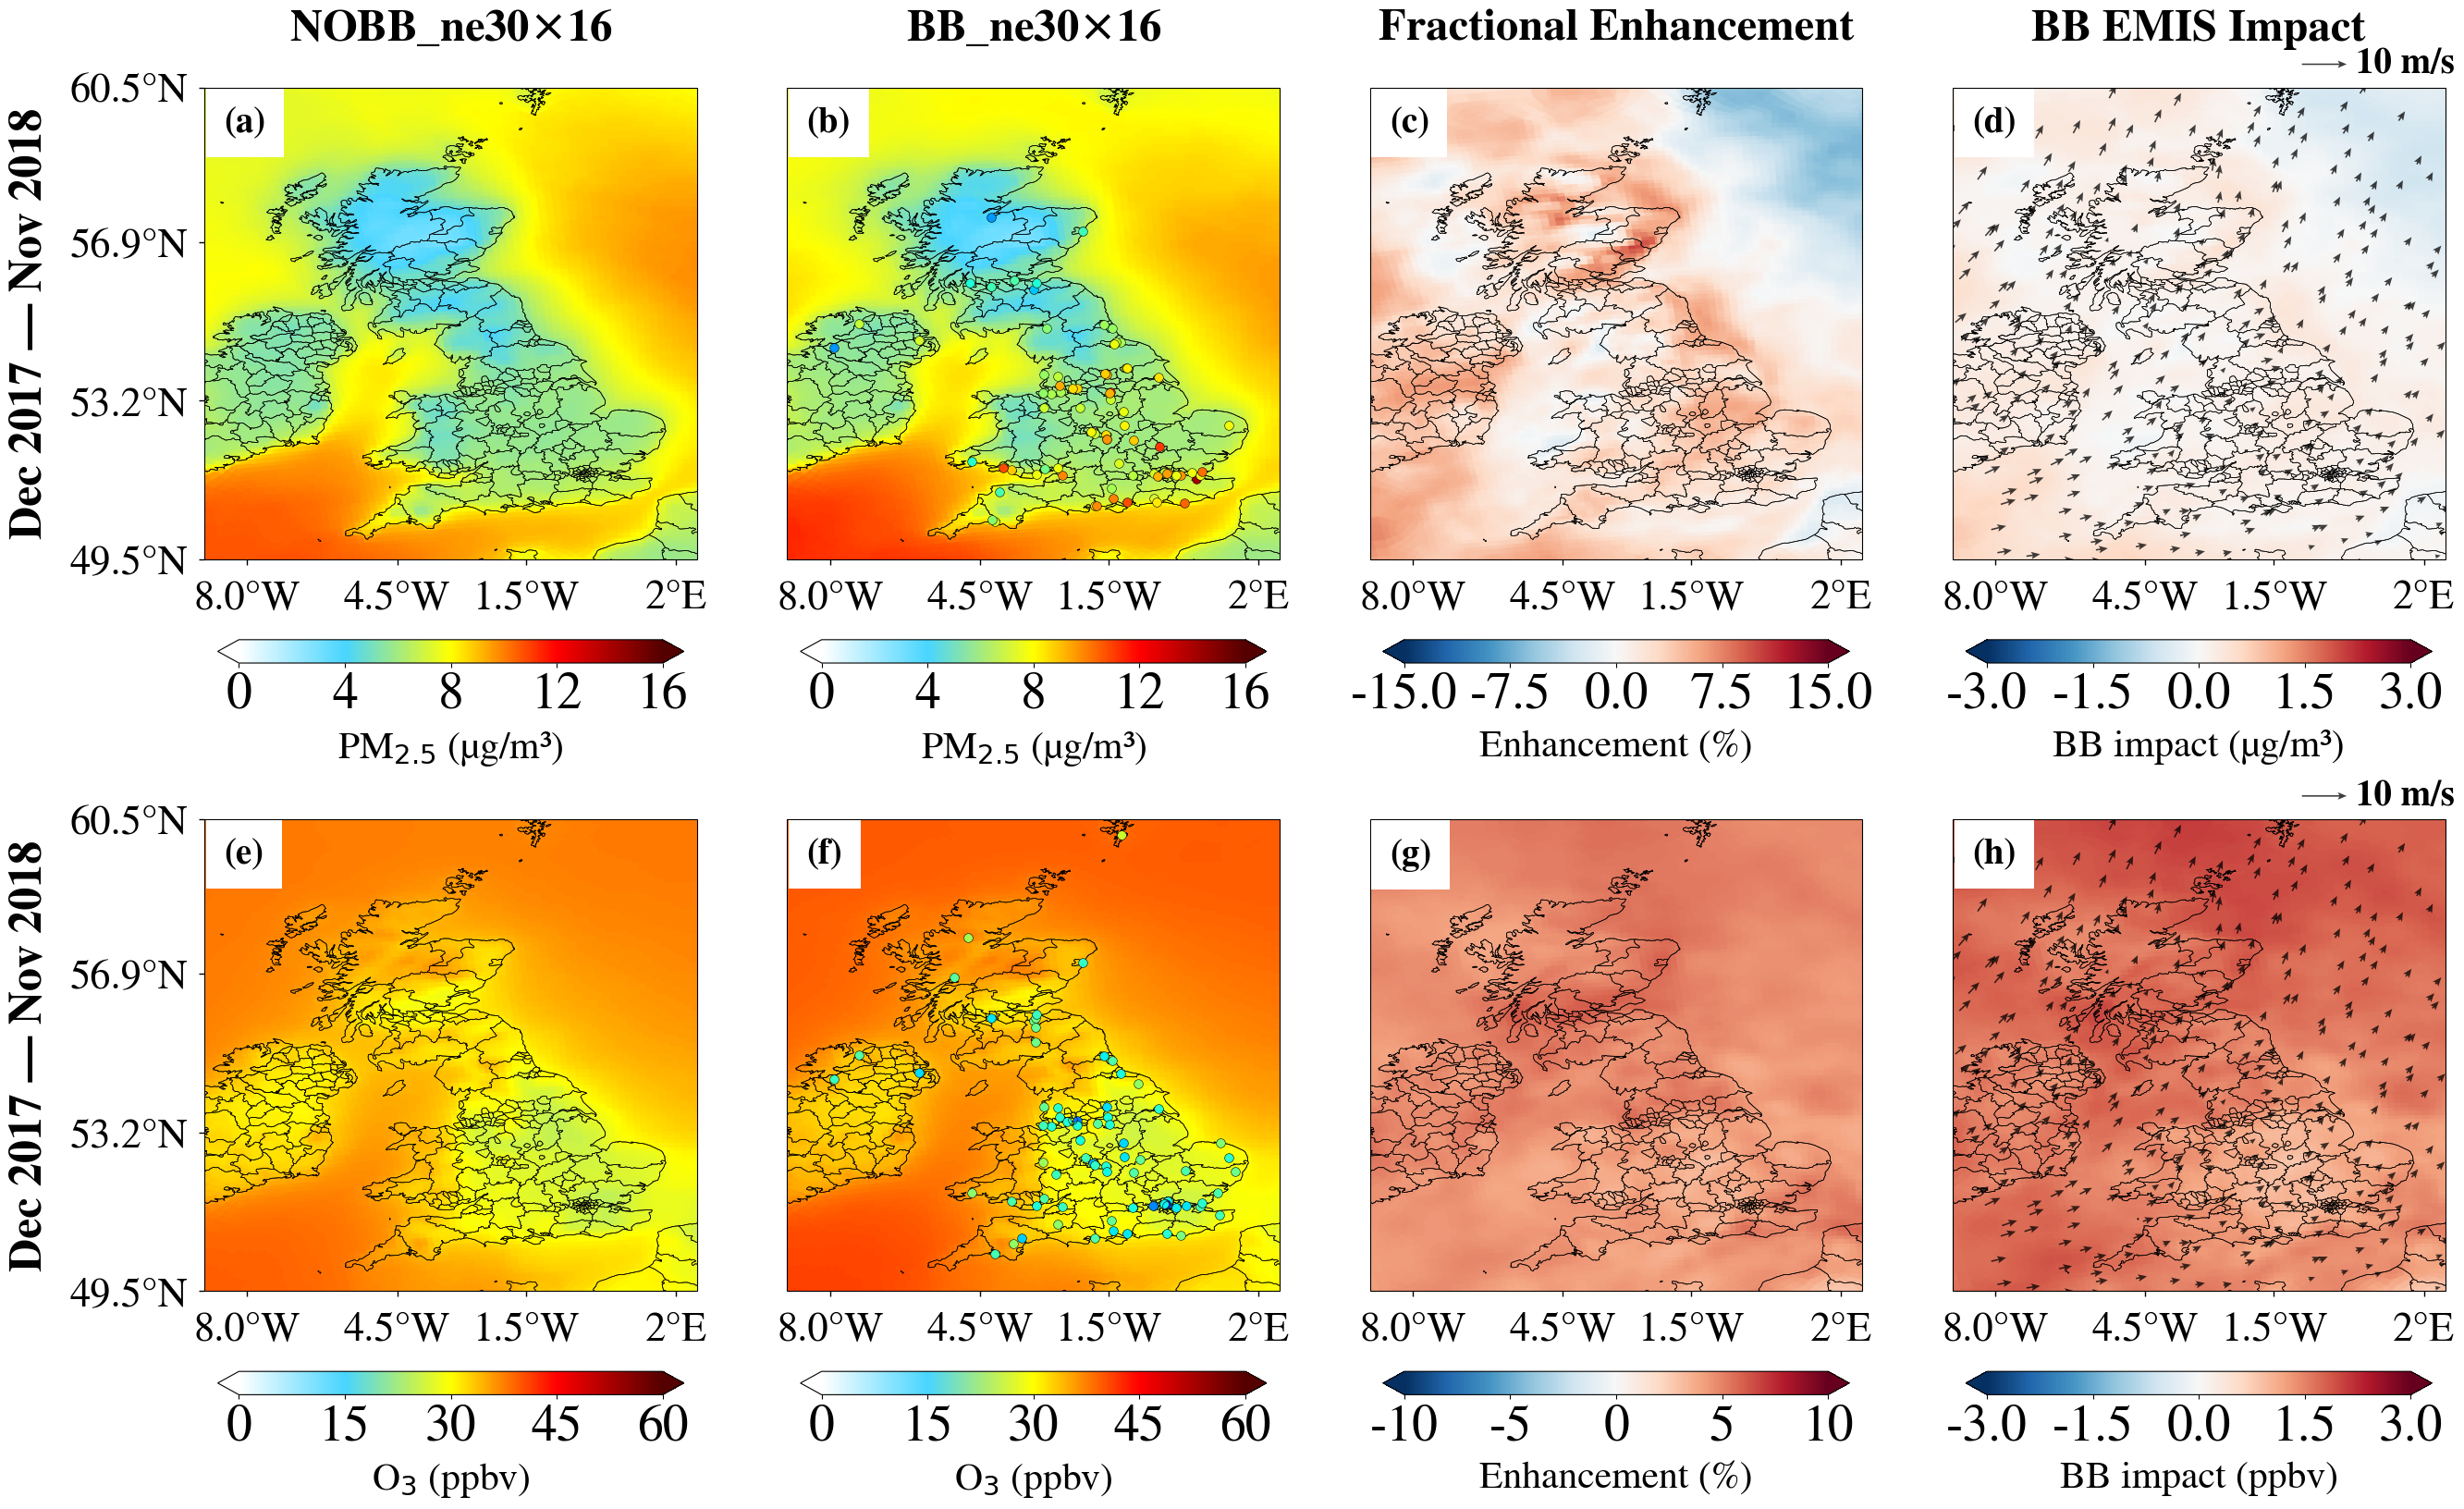

In [9]:
average_data_NOBB = annual_average(file_paths_NOBB)
average_data_BB = annual_average(file_paths_BB)

pm25_obs_lat, pm25_obs_lon, pm25_obs_color = obs_for_pm25(support_months)
o3_obs_lat, o3_obs_lon, o3_obs_color = obs_for_o3(support_months)

pm25_data_NOBB = average_data_NOBB['PM25'].isel(lev=-1) * 1e9
pm25_data_BB = average_data_BB['PM25'].isel(lev=-1) * 1e9
pm25_data_rel = (pm25_data_BB - pm25_data_NOBB) / pm25_data_NOBB * 100
pm25_data_diff = pm25_data_BB - pm25_data_NOBB

o3_data_NOBB = average_data_NOBB['O3'].isel(lev=-1) * 1e9
o3_data_BB = average_data_BB['O3'].isel(lev=-1) * 1e9
o3_data_rel = (o3_data_BB - o3_data_NOBB) / o3_data_NOBB * 100
o3_data_diff = o3_data_BB - o3_data_NOBB

raw_rows = [
    {
        'species': 'pm25',
        'label': row_label,
        'nobb': pm25_data_NOBB,
        'bb': pm25_data_BB,
        'rel': pm25_data_rel,
        'diff': pm25_data_diff,
        'u': average_data_BB['U'].isel(lev=-1).values,
        'v': average_data_BB['V'].isel(lev=-1).values,
        'obs_lat': pm25_obs_lat,
        'obs_lon': pm25_obs_lon,
        'obs_color': pm25_obs_color,
    },
    {
        'species': 'o3',
        'label': row_label,
        'nobb': o3_data_NOBB,
        'bb': o3_data_BB,
        'rel': o3_data_rel,
        'diff': o3_data_diff,
        'u': average_data_BB['U'].isel(lev=-1).values,
        'v': average_data_BB['V'].isel(lev=-1).values,
        'obs_lat': o3_obs_lat,
        'obs_lon': o3_obs_lon,
        'obs_color': o3_obs_color,
    },
]

fig, axs = plot_figure_s13(raw_rows, scrip_filename)


In [4]:
os.makedirs(figure_data_dir, exist_ok=True)

with xr.open_dataset(scrip_filename) as grid:
    figure_s13_data = xr.Dataset(
        data_vars={
            "pm25_nobb": (("ncol",), pm25_data_NOBB.values.astype(np.float64)),
            "pm25_bb": (("ncol",), pm25_data_BB.values.astype(np.float64)),
            "pm25_fractional_enhancement": (("ncol",), pm25_data_rel.values.astype(np.float64)),
            "pm25_bb_emis_impact": (("ncol",), pm25_data_diff.values.astype(np.float64)),
            "pm25_u": (("ncol",), average_data_BB['U'].isel(lev=-1).values.astype(np.float64)),
            "pm25_v": (("ncol",), average_data_BB['V'].isel(lev=-1).values.astype(np.float64)),
            "pm25_obs_color": (("pm25_obs_site",), np.asarray(pm25_obs_color, dtype=np.float64)),
            "pm25_obs_lat": (("pm25_obs_site",), np.asarray(pm25_obs_lat, dtype=np.float64)),
            "pm25_obs_lon": (("pm25_obs_site",), np.asarray(pm25_obs_lon, dtype=np.float64)),
            "o3_nobb": (("ncol",), o3_data_NOBB.values.astype(np.float64)),
            "o3_bb": (("ncol",), o3_data_BB.values.astype(np.float64)),
            "o3_fractional_enhancement": (("ncol",), o3_data_rel.values.astype(np.float64)),
            "o3_bb_emis_impact": (("ncol",), o3_data_diff.values.astype(np.float64)),
            "o3_u": (("ncol",), average_data_BB['U'].isel(lev=-1).values.astype(np.float64)),
            "o3_v": (("ncol",), average_data_BB['V'].isel(lev=-1).values.astype(np.float64)),
            "o3_obs_color": (("o3_obs_site",), np.asarray(o3_obs_color, dtype=np.float64)),
            "o3_obs_lat": (("o3_obs_site",), np.asarray(o3_obs_lat, dtype=np.float64)),
            "o3_obs_lon": (("o3_obs_site",), np.asarray(o3_obs_lon, dtype=np.float64)),
            "grid_center_lon": (("ncol",), grid["grid_center_lon"].values.astype(np.float64)),
            "grid_center_lat": (("ncol",), grid["grid_center_lat"].values.astype(np.float64)),
            "grid_corner_lon": (("ncol", "grid_corner"), grid["grid_corner_lon"].values.astype(np.float64)),
            "grid_corner_lat": (("ncol", "grid_corner"), grid["grid_corner_lat"].values.astype(np.float64)),
            "grid_area": (("ncol",), grid["grid_area"].values.astype(np.float64)),
        },
        coords={
            "ncol": np.arange(grid["grid_center_lon"].size, dtype=np.int32),
            "grid_corner": np.arange(grid["grid_corner_lon"].shape[1], dtype=np.int32),
            "pm25_obs_site": np.arange(len(pm25_obs_lat), dtype=np.int32),
            "o3_obs_site": np.arange(len(o3_obs_lat), dtype=np.int32),
            "month": support_months,
        },
    )

figure_s13_data.attrs = {"period": row_label}
for name in list(figure_s13_data.data_vars) + list(figure_s13_data.coords):
    figure_s13_data[name].attrs = {}

figure_s13_data.to_netcdf(figure_s13_nc)
figure_s13_data.close()
figure_s13_nc


'/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS13.nc'

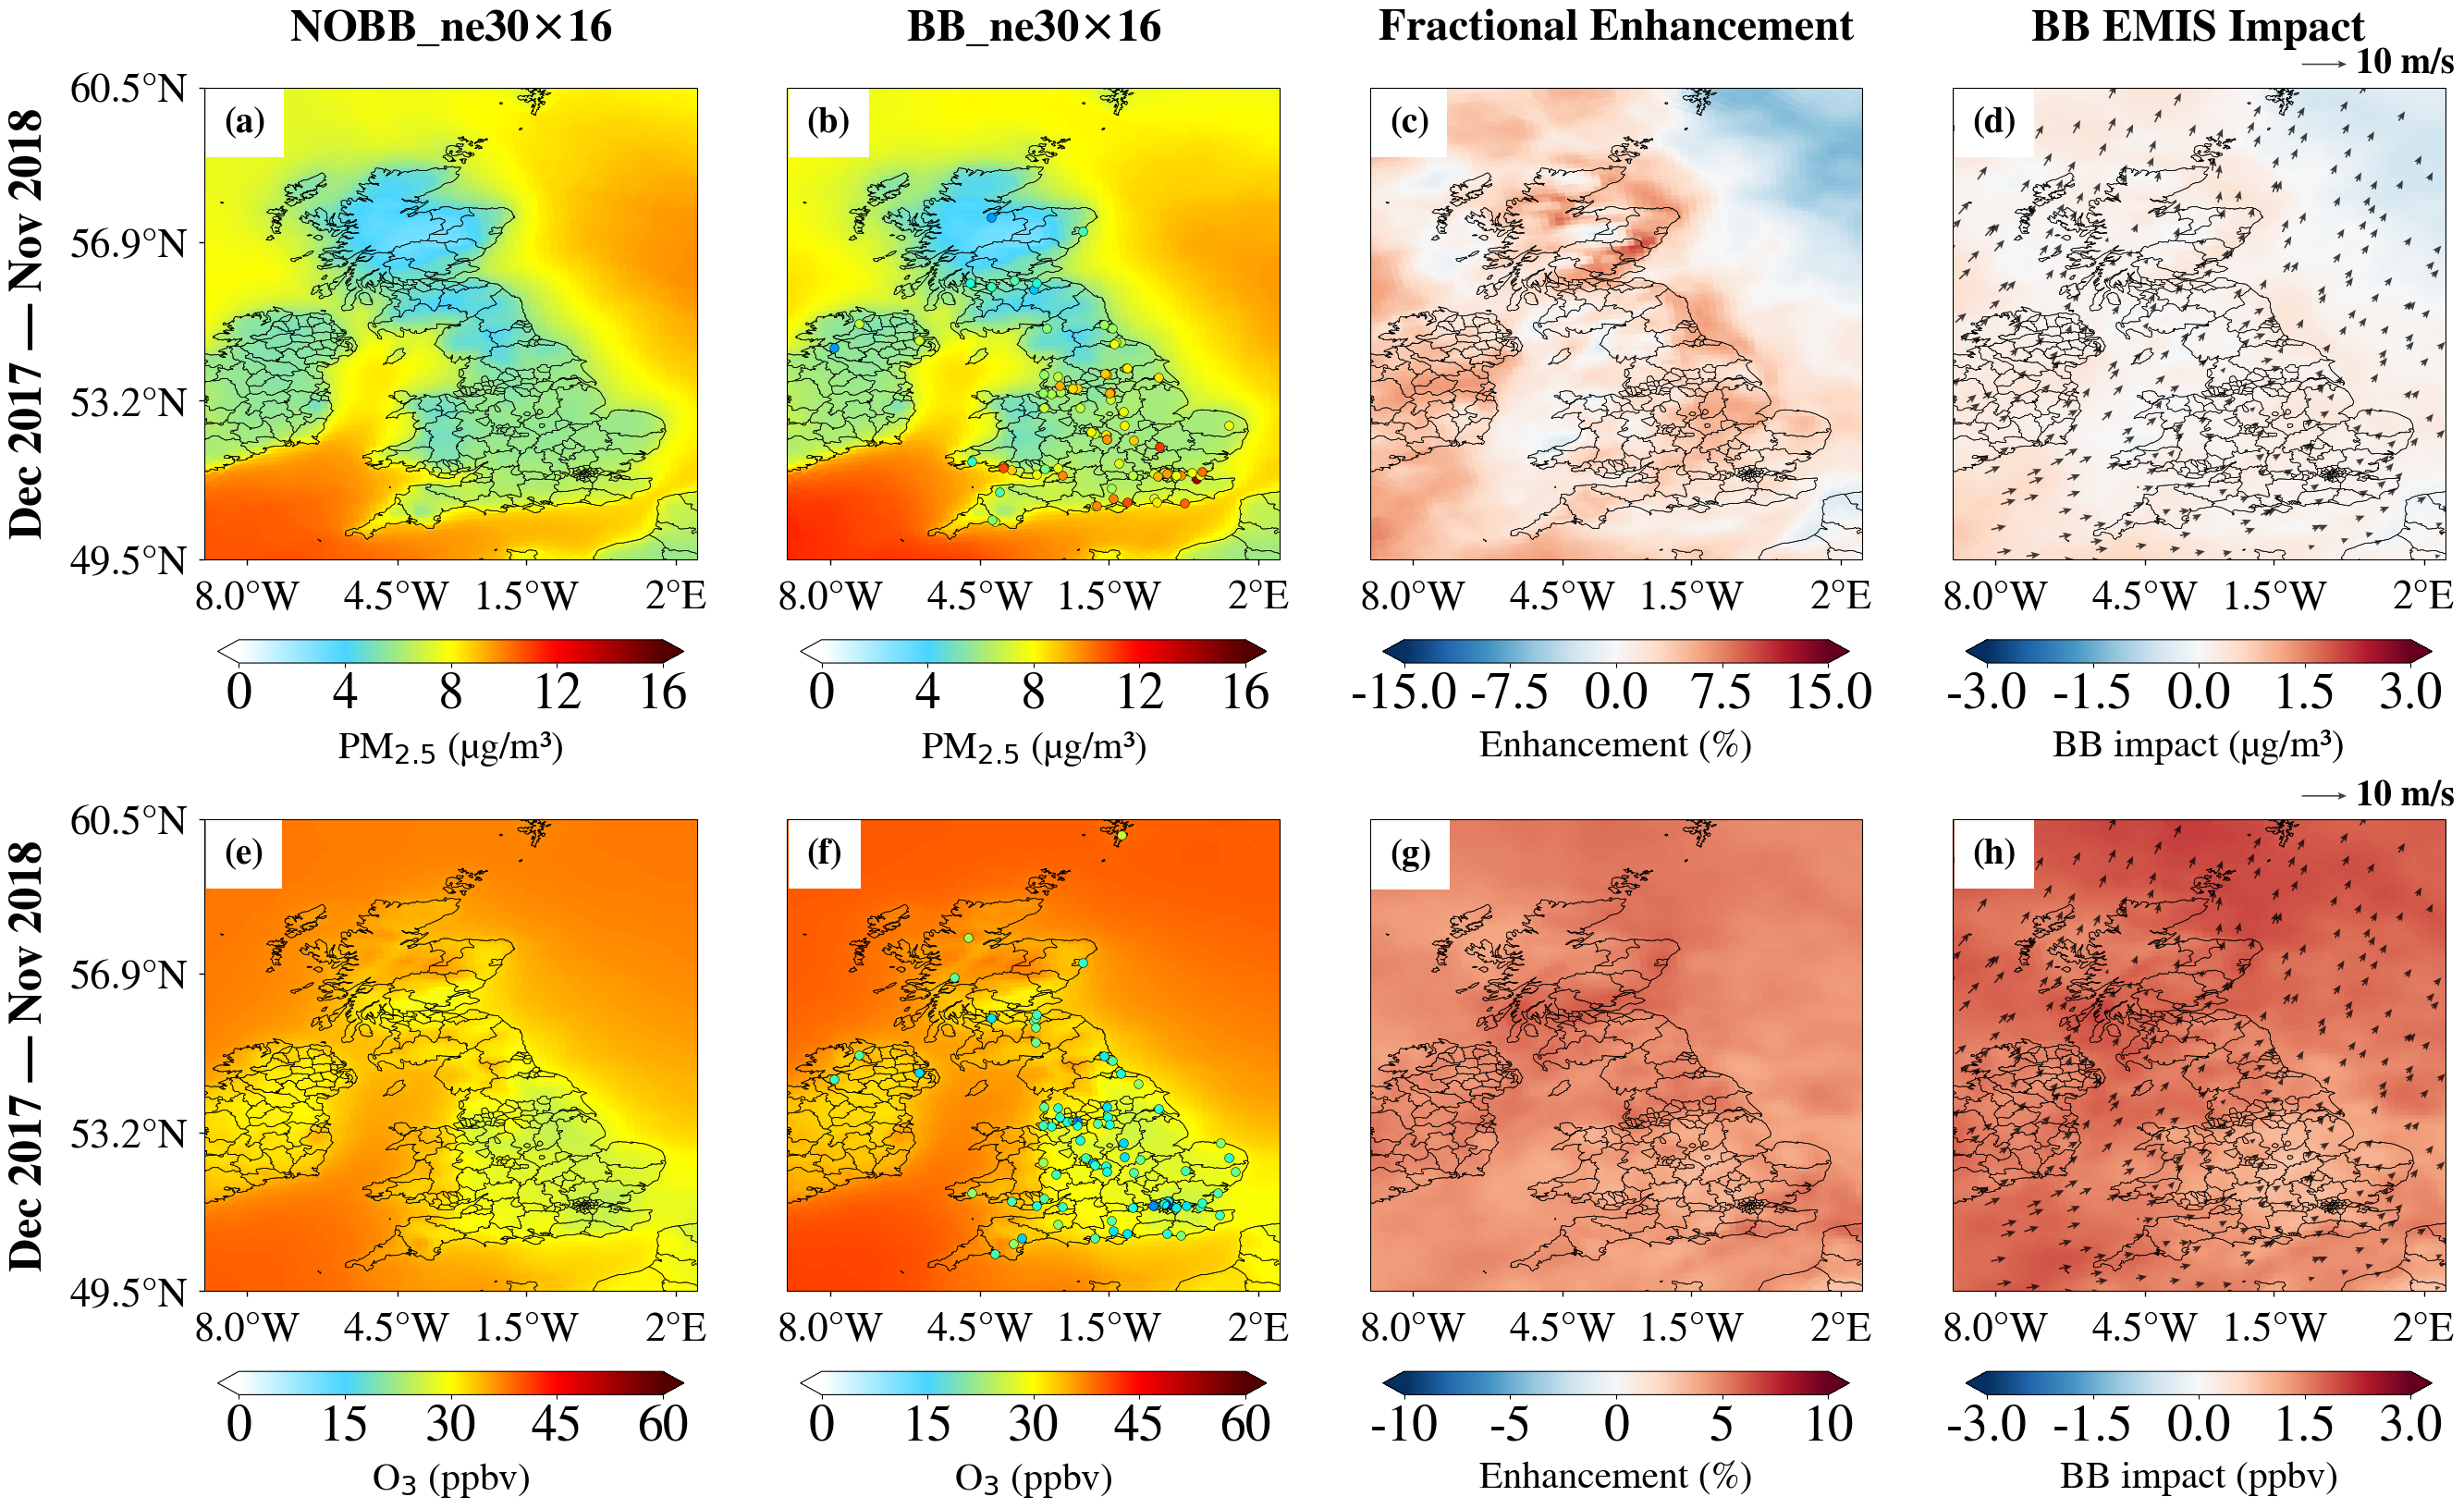

In [ ]:
figure_s13_nc = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS13.nc"
figure_s13_saved = xr.open_dataset(figure_s13_nc)

scrip_saved = xr.Dataset(
    data_vars={
        "grid_center_lon": (("ncol",), figure_s13_saved["grid_center_lon"].values),
        "grid_center_lat": (("ncol",), figure_s13_saved["grid_center_lat"].values),
        "grid_corner_lon": (("ncol", "grid_corner"), figure_s13_saved["grid_corner_lon"].values),
        "grid_corner_lat": (("ncol", "grid_corner"), figure_s13_saved["grid_corner_lat"].values),
        "grid_area": (("ncol",), figure_s13_saved["grid_area"].values),
    }
)

saved_rows = [
    {
        'species': 'pm25',
        'label': row_label,
        'nobb': xr.DataArray(figure_s13_saved['pm25_nobb'].values, dims=["ncol"]),
        'bb': xr.DataArray(figure_s13_saved['pm25_bb'].values, dims=["ncol"]),
        'rel': xr.DataArray(figure_s13_saved['pm25_fractional_enhancement'].values, dims=["ncol"]),
        'diff': xr.DataArray(figure_s13_saved['pm25_bb_emis_impact'].values, dims=["ncol"]),
        'u': figure_s13_saved['pm25_u'].values,
        'v': figure_s13_saved['pm25_v'].values,
        'obs_lat': figure_s13_saved['pm25_obs_lat'].values,
        'obs_lon': figure_s13_saved['pm25_obs_lon'].values,
        'obs_color': figure_s13_saved['pm25_obs_color'].values,
    },
    {
        'species': 'o3',
        'label': row_label,
        'nobb': xr.DataArray(figure_s13_saved['o3_nobb'].values, dims=["ncol"]),
        'bb': xr.DataArray(figure_s13_saved['o3_bb'].values, dims=["ncol"]),
        'rel': xr.DataArray(figure_s13_saved['o3_fractional_enhancement'].values, dims=["ncol"]),
        'diff': xr.DataArray(figure_s13_saved['o3_bb_emis_impact'].values, dims=["ncol"]),
        'u': figure_s13_saved['o3_u'].values,
        'v': figure_s13_saved['o3_v'].values,
        'obs_lat': figure_s13_saved['o3_obs_lat'].values,
        'obs_lon': figure_s13_saved['o3_obs_lon'].values,
        'obs_color': figure_s13_saved['o3_obs_color'].values,
    },
]

fig, axs = plot_figure_s13(saved_rows, scrip_saved)

FIGURES_DIR = Path("/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RASTER_DPI = 300
png_path = FIGURES_DIR / "FigureS13.png"
pdf_path = FIGURES_DIR / "FigureS13.pdf"

fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches="tight", facecolor="white")

img = plt.imread(png_path)
height_px, width_px = img.shape[:2]
pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
pdf_ax.imshow(img)
pdf_ax.axis("off")
pdf_fig.savefig(pdf_path, format="pdf", dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor="white")
plt.close(pdf_fig)
